## WeatherAnalyze

## Importer

In [42]:
import requests
import json
import matplotlib.pyplot as plt

print("Nödvändiga importer laddade!")


Nödvändiga importer laddade!


In [43]:
# Dictionary med koordinater för de valbara städerna inför anrop till API

cities = {
    "Stockholm": [59.33, 18.07],
    "Göteborg": [57.71, 11.97],
    "Malmö": [55.61, 13.00]
}


print(f"Skriver ut testkoordinater för Sthlm: {cities["Stockholm"]}")

Skriver ut testkoordinater för Sthlm: [59.33, 18.07]


## Funktion för att ta emot användarens val av stad

In [44]:
def get_city():
    print("Välj stad för att hämta ett dygns väderprognos:")
    print("1. Stockholm")
    print("2. Göteborg")
    print("3. Malmö\n")

    while True:
        choice = input("Ange vilken stad du vill hämta prognosen ifrån (1-3):")
        
        if choice == "1":
            return "Stockholm"
        elif choice == "2":
            return "Göteborg"
        elif choice == "3":
            return "Malmö"
        else:
            print("Du måste välja en siffra (1-3)!")

city = get_city()
latitude, longitude = cities[city]

print(f"Vald stad: {city}")
print(f"Koordinater: {latitude}, {longitude}")

    

Välj stad för att hämta ett dygns väderprognos:
1. Stockholm
2. Göteborg
3. Malmö

Vald stad: Stockholm
Koordinater: 59.33, 18.07


## Funktion för att låta användaren välja om den vill visa mer information.

In [45]:
def get_detailed_info():
    while True:
        extra_choice = input("Vill du visa detaljerad information om vind? (j/n): ")
        if extra_choice == "j":
            return True
        elif extra_choice == "n":
            return False
        else:
            print("Du måste välja: (j/n)! ")

detailed_info = get_detailed_info()

print(f"Visa vindinformation: {detailed_info}")

Visa vindinformation: True


## Funktion för API-anrop

In [46]:
def get_weather(latitude, longitude):
    url = "https://api.open-meteo.com/v1/forecast"

    weather_parameters = {
        "latitude": latitude,
        "longitude": longitude,
        "hourly": "temperature_2m,wind_speed_10m",
        "forecast_days": 1
    }

    try:
        response = requests.get(url, params=weather_parameters)
        response.raise_for_status()
        data = response.json()
        
        temperature = data["hourly"]["temperature_2m"]
        weather_time = data["hourly"]["time"]
        wind = data["hourly"]["wind_speed_10m"]
    
        return temperature, weather_time, wind

    except requests.exceptions.RequestException:
        print("Kunde inte hämta väderdata från API.")
        return None, None, None

    except KeyError:
        print("Förväntad data saknas i API-svaret.")
        return None, None, None

temperature, weather_time, wind = get_weather(latitude, longitude)

if temperature is not None:
    print("Api-anrop lyckades!")
    print(f"Hämtade {len(temperature)} temperaturvärden.")
    print(f"Första tidpunkten: {weather_time[0]}")
    print(f"Första temperaturen: {temperature[0]} °C")
    



Api-anrop lyckades!
Hämtade 24 temperaturvärden.
Första tidpunkten: 2026-10-01T00:00
Första temperaturen: 14.2 °C


## Klasser och OOP

In [47]:
# Skapar en väder-klass

class Weather:
    def __init__(self, city, temperature, weather_time):
        self.city = city
        self.temperature = temperature
        self.time = weather_time

    def __str__(self):
        return f"Temperaturen i {self.city} är {self.temperature}°C, tidpunkt: {self.time}"

class DetailedWeather(Weather):
    def __init__(self, city, temperature, weather_time, wind):
        super().__init__(city, temperature, weather_time)
        self.wind = wind

    def __str__(self):
        return f"Temperaturen i {self.city} är {self.temperature}°C, tidpunkt: {self.time}, vindhastighet: {self.wind}."

weather_example = Weather("Stockholm", 20.5, "12:00")
detailed_example = DetailedWeather("Stockholm", 20.5, "12:00", 4.2)

print("Skriver ut exempel på föräldraklass och barnklass:\n")
print(f"Föräldraklass: {weather_example}")
print(f"Barnklass: {detailed_example}")


Skriver ut exempel på föräldraklass och barnklass:

Föräldraklass: Temperaturen i Stockholm är 20.5°C, tidpunkt: 12:00
Barnklass: Temperaturen i Stockholm är 20.5°C, tidpunkt: 12:00, vindhastighet: 4.2.


## Skapa och visa väderobjekt för varje timme

Den hämtade väderdatan omvandlas till ett väderobjekt för varje timme.

In [48]:
weather_history = []

if temperature is not None:
    for i in range(len(weather_time)):
        if detailed_info:
            weather_object = DetailedWeather(
            city,
            temperature[i],
            weather_time[i],
            wind[i]
            )
        else:
            weather_object = Weather(
                city,
                temperature[i],
                weather_time[i]
            )
        weather_history.append(weather_object)

    print(f"Antal väderobjekt i historiken: {len(weather_history)}")
    print(f"Exempel på väderobjekt: {weather_history[0]}")



Antal väderobjekt i historiken: 24
Exempel på väderobjekt: Temperaturen i Stockholm är 14.2°C, tidpunkt: 2026-10-01T00:00, vindhastighet: 13.0.


## Spara den hämtade datan

In [49]:
def save_weather(weather_history):
    weather_data = []

    for weather_object in weather_history:
        data = {
            "city": weather_object.city,
            "temperature": weather_object.temperature,
            "time": weather_object.time
        }

        if isinstance(weather_object, DetailedWeather):
            data["wind"] = weather_object.wind

        weather_data.append(data)

    try:
        with open("weather_data.json", "r", encoding="utf-8") as file:
            old_data = json.load(file)
    except FileNotFoundError:
        old_data = []

    old_data.extend(weather_data)

    with open("weather_data.json", "w", encoding="utf-8") as file:
        json.dump(old_data, file, indent=4, ensure_ascii=False)

if temperature is not None:
    save_weather(weather_history)
    print("Den hämtade datan har sparats i JSON-filen!")


Den hämtade datan har sparats i JSON-filen!


## Analys av väderdata

In [50]:
def analyze_temperature(temperature, city):
    min_temperature = min(temperature)
    max_temperature = max(temperature)
    avg_temperature = sum(temperature) / len(temperature)

    print(f"Kortfattad analys av prognosen för {city} det kommande dygnet: ")
    print(f"Lägsta temperatur: {min_temperature}°C")
    print(f"Högsta temperatur: {max_temperature}°C")
    print(f"Medeltemperatur: {avg_temperature:.1f}°C")

if temperature is not None:
    analyze_temperature(temperature, city)

Kortfattad analys av prognosen för Stockholm det kommande dygnet: 
Lägsta temperatur: 13.6°C
Högsta temperatur: 18.5°C
Medeltemperatur: 15.5°C


## Funktion för att visa hur temperaturen ändras över tid


Visar diagram över prognosen för temperaturen kommande dygn i Stockholm:
 


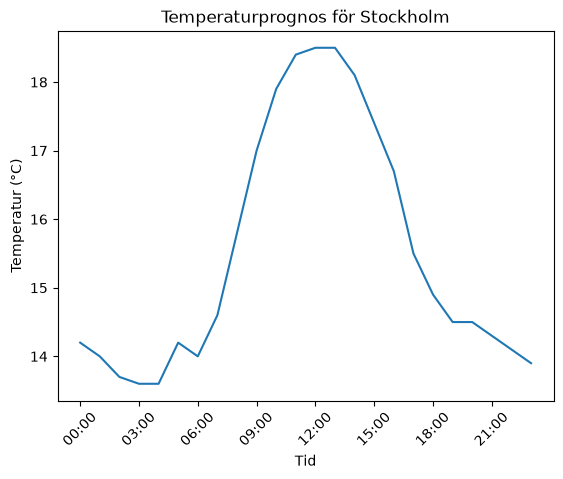

Visar diagram över prognosen för vindhastigheten kommande dygn i Stockholm:
 


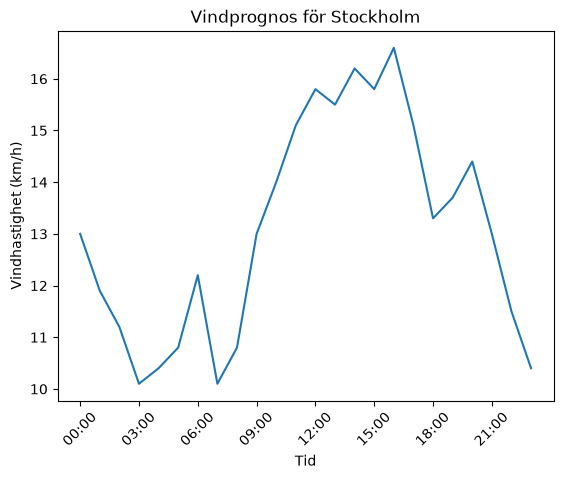

In [51]:
def plot_temperature(weather_time, temperature, city):
    time_labels = []

    # Plockar ut klockslaget från varje värde i weather_time och sparar det i time_labels
    for time in weather_time:
        time_labels.append(time[11:16])

    plt.plot(time_labels, temperature)

    plt.xlabel("Tid")
    plt.ylabel("Temperatur (°C)")
    plt.title(f"Temperaturprognos för {city}")

    plt.xticks(time_labels[::3], rotation=45)
    plt.show()

def plot_wind (weather_time, wind, city):
    time_labels = []

    # Plockar ut klockslaget från varje värde i weather_time och sparar det i time_labels
    for time in weather_time:
        time_labels.append(time[11:16])

    plt.plot(time_labels, wind)

    plt.xlabel("Tid")
    plt.ylabel("Vindhastighet (km/h)")
    plt.title(f"Vindprognos för {city}")

    plt.xticks(time_labels[::3], rotation=45)
    plt.show()

if temperature is not None:
    print(f"\nVisar diagram över prognosen för temperaturen kommande dygn i {city}:\n ")
    plot_temperature(weather_time, temperature, city)

    if detailed_info:
        print(f"Visar diagram över prognosen för vindhastigheten kommande dygn i {city}:\n ")
        plot_wind(weather_time, wind, city)

## Förberedelse av data för AI-modell

Vid eventuell framtida användning av datan i en AI-modell så är det bra att rensa bort orimliga värden för att undvika att felaktig data påverkar modellen.

Därefter normaliseras datan till värden mellan 0 och 1. Det är särskilt användbart när man har flera numeriska features (indata) med olika skalor.

In [52]:
def clean_temperature_data(temperature):
    cleaned_temperature = []

    for value in temperature:
        if -40 <= value <= 40:
            cleaned_temperature.append(value)

    return cleaned_temperature

def clean_wind_data(wind):
    cleaned_wind = []

    for value in wind:
        if 0 <= value <= 150:
            cleaned_wind.append(value)

    return cleaned_wind



if temperature is not None:
    cleaned_temperature = clean_temperature_data(temperature)

    print(f"Antal temperaturvärden före rensning: {len(temperature)}")
    print(f"Antal temperaturvärden efter rensning: {len(cleaned_temperature)}")

    if detailed_info:
        cleaned_wind = clean_wind_data(wind)

        print(f"Antal vindvärden före rensning: {len(wind)}")
        print(f"Antal vindvärden efter rensning: {len(cleaned_wind)}")


Antal temperaturvärden före rensning: 24
Antal temperaturvärden efter rensning: 24
Antal vindvärden före rensning: 24
Antal vindvärden efter rensning: 24


In [ ]:
def normalize_data(values):
    normalized_values = []

    if not values:
        return None

    min_value = min(values)
    max_value = max(values)

    if min_value == max_value:
        print("Kan inte normalisera data eftersom alla värden är lika.")
        return None
    
    for value in values:
        normalized_value = (value - min_value) / (max_value - min_value)
        normalized_values.append(round(normalized_value, 3))

    return normalized_values

    

if temperature is not None:
    normalized_temperature = normalize_data(cleaned_temperature)
    print("Normaliserad temperaturdata:")
    print(normalized_temperature)

    if detailed_info:
        normalized_wind = normalize_data(cleaned_wind)
        print("Normaliserad vinddata:")
        print(normalized_wind)
        


Normaliserad temperaturdata:
[0.122, 0.082, 0.02, 0.0, 0.0, 0.122, 0.082, 0.204, 0.449, 0.694, 0.878, 0.98, 1.0, 1.0, 0.918, 0.776, 0.633, 0.388, 0.265, 0.184, 0.184, 0.143, 0.102, 0.061]
Normaliserad vinddata:
[0.446, 0.277, 0.169, 0.0, 0.046, 0.108, 0.323, 0.0, 0.108, 0.446, 0.6, 0.769, 0.877, 0.831, 0.938, 0.877, 1.0, 0.769, 0.492, 0.554, 0.662, 0.446, 0.215, 0.046]
